# Steam 玩家反馈与热度分析

本 Notebook 延续前面三个阶段的结果，重点分析 Steam 游戏的玩家反馈与热度指标。

在本项目中，玩家反馈和热度不会被理解成一个单一变量，而是由多个代理指标共同描述：评论数量、好评率、推荐数、峰值在线人数和游玩时长。这样做更符合真实平台数据的特点，因为“被很多人玩”“被很多人评价”和“评价更正面”并不总是同一件事。

本 Notebook 只做描述性分析和可视化，不训练预测模型，也不做推荐系统。

## 1. 读取特征数据与环境检查

本节读取 Notebook 03 生成的 `steam_march2025_features.parquet`。这个文件已经完成基础清洗和特征工程，因此本 Notebook 不再重复读取几百 MB 的原始 CSV。

如果该文件不存在，需要先运行 Notebook 03。

In [1]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw" / "archive"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH = PROCESSED_DIR / "steam_march2025_features.parquet"
if not FEATURE_PATH.exists():
    raise FileNotFoundError(
        f"未找到 {FEATURE_PATH}。请先运行 notebooks/03_steam_data_cleaning_and_features.ipynb。"
    )

df = pd.read_parquet(FEATURE_PATH)
print(f"Loaded: {FEATURE_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_features.parquet
Shape: 89,618 rows x 63 columns


,appid,name,release_date,required_age,price,discount,dlc_count,windows,mac,linux,metacritic_score,achievements,recommendations,developers,publishers,categories,genres,user_score,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,supported_languages,full_audio_languages,short_description,about_the_game,release_date_parsed,release_year,game_age_years,genres_list,genres_count,categories_list,categories_count,tags_list,tags_count,developers_list,developers_count,publishers_list,publishers_count,supported_languages_list,supported_languages_count,full_audio_languages_list,full_audio_languages_count,is_free,platform_count,is_multi_platform,review_count_calc,positive_rate_calc,negative_rate_calc,short_description_length,about_the_game_length,has_peak_ccu,peak_ccu_log1p,recommendations_log1p
0,730,Counter-Strike 2,2012-08-21,0,0.000,0,1,True,False,True,0,1,4401572,['Valve'],['Valve'],"['Multi-player', 'Cross-Platform Multiplayer',...","['Action', 'Free To Play']",0,7480813,1135108,100000000 - 200000000,33189,879,5174,350,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86.000,8632939,82.000,96473,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",2012-08-21,2012,14.000,Action|Free To Play,2,Multi-player|Cross-Platform Multiplayer|Steam ...,11,FPS|Shooter|Multiplayer|Competitive|Action|Tea...,20,Valve,1,Valve,1,Czech|Danish|Dutch|English|Finnish|French|Germ...,29,English|Indonesian,2,True,2,True,8615921,86.825,13.175,224,879,True,14.008,15.297
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.000,0,0,True,False,False,0,37,1732007,['PUBG Corporation'],"['KRAFTON, Inc.']","['Multi-player', 'PvP', 'Online PvP', 'Stats',...","['Action', 'Adventure', 'Massively Multiplayer...",0,1487960,1024436,50000000 - 100000000,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59.000,2513842,68.000,16720,"['English', 'Korean', 'Simplified Chinese', 'F...",[],Play PUBG: BATTLEGROUNDS for free. Land on str...,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",2017-12-21,2017,9.000,Action|Adventure|Massively Multiplayer|Free To...,4,Multi-player|PvP|Online PvP|Stats|Remote Play ...,6,Survival|Shooter|Battle Royale|Multiplayer|FPS...,20,PUBG Corporation,1,"KRAFTON, Inc.",1,English|Korean|Simplified Chinese|French|Germa...,17,,0,True,1,False,2512396,59.225,40.775,293,478,True,13.332,14.365
2,570,Dota 2,2013-07-09,0,0.000,0,2,True,True,True,90,0,14337,['Valve'],['Valve'],"['Multi-player', 'Co-op', 'Steam Trading Cards...","['Action', 'Strategy', 'Free To Play']",0,1998462,451338,200000000 - 500000000,43031,1536,898,892,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81.000,2452595,80.000,29366,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...","Every day, millions of players worldwide enter...","The most-played game on Steam. Every day, mill...",2013-07-09,2013,13.000,Action|Strategy|Free To Play,3,Multi-player|Co-op|Steam Trading Cards|Steam W...,8,Free to Play|MOBA|Multiplayer|Strategy|e-sport...,20,Valve,1,Valve,1,Bulgarian|Czech|Danish|Dutch|English|Finnish|F...,28,English|Korean|Simplified Chinese|Vietnamese,4,True,3,True,2449800,81.577,18.423,319,1402,True,13.228,9.571
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.000,0,0,True,False,False,96,77,1803063,['Rockstar North'],['Rockstar Games'],"['Single-player', 'Multi-player', 'PvP', 'Onli...","['Action', 'Adventure']",0,1719950,250012,50000000 - 100000000,19323,771,7101,74,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87.000,1803832,92.000,17517,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']",Grand Theft Auto V for PC offers players the o...,"When a young street hustler, 

In [2]:
# 检查本 Notebook 需要的关键字段。
required_columns = [
    "appid", "name", "release_year", "game_age_years", "price", "is_free",
    "platform_count", "is_multi_platform", "genres", "tags",
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
    "average_playtime_forever", "median_playtime_forever"
]
column_check = pd.DataFrame({
    "column": required_columns,
    "exists": [col in df.columns for col in required_columns]
})
display(column_check)
missing = column_check.loc[~column_check["exists"], "column"].tolist()
if missing:
    print("Warning: 以下字段缺失，相关分析会跳过或降级：", missing)
else:
    print("All required columns are available.")

,column,exists
0,appid,True
1,name,True
2,release_year,True
3,game_age_years,True
4,price,True
5,is_free,True
6,platform_count,True
7,is_multi_platform,True
8,genres,True
9,tags,True


All required columns are available.


## 2. 定义反馈与热度指标

本项目把玩家反馈与热度拆成几类指标：

- `review_count_calc`：正面评论数与负面评论数之和，可以作为玩家参与评价的规模指标；
- `positive_rate_calc`：正面评论占比，可以作为玩家反馈倾向指标；
- `recommendations`：Steam 推荐数，反映另一种平台热度信号；
- `peak_ccu`：峰值同时在线人数，更接近实时热度；
- `average_playtime_forever`、`median_playtime_forever`：历史游玩时长指标。

这些指标分布都非常长尾，所以本 Notebook 会构造对应的 `log1p` 变量，用来让图表更容易阅读。

In [3]:
analysis_df = df.copy()

numeric_cols = [
    "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
    "average_playtime_forever", "median_playtime_forever", "price", "platform_count",
    "release_year", "game_age_years"
]
for col in numeric_cols:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

for col in ["review_count_calc", "recommendations", "peak_ccu", "average_playtime_forever", "median_playtime_forever"]:
    if col in analysis_df.columns:
        analysis_df[f"{col}_log1p"] = np.log1p(analysis_df[col].clip(lower=0))

analysis_df["has_reviews"] = analysis_df["review_count_calc"].fillna(0) > 0
analysis_df["has_reliable_positive_rate"] = analysis_df["review_count_calc"].fillna(0) >= 30
analysis_df["has_peak_ccu_value"] = analysis_df["peak_ccu"].fillna(0) > 0
analysis_df["has_playtime_value"] = analysis_df["average_playtime_forever"].fillna(0) > 0

# 固定价格分组，便于解释。免费游戏单独作为一类。
price_bins = [-0.001, 0, 4.99, 9.99, 19.99, 39.99, np.inf]
price_labels = ["Free", "<$5", "$5-$10", "$10-$20", "$20-$40", "$40+"]
analysis_df["price_bucket"] = pd.cut(
    analysis_df["price"].fillna(0),
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

# 一个描述性综合热度分数：只是把几个 log 指标标准化后求平均，不用于预测。
attention_components = ["review_count_calc_log1p", "recommendations_log1p", "peak_ccu_log1p"]
valid_components = [col for col in attention_components if col in analysis_df.columns]
for col in valid_components:
    std = analysis_df[col].std()
    analysis_df[f"{col}_z"] = (analysis_df[col] - analysis_df[col].mean()) / std if std and not np.isnan(std) else 0
z_cols = [f"{col}_z" for col in valid_components]
analysis_df["attention_score_descriptive"] = analysis_df[z_cols].mean(axis=1) if z_cols else np.nan

metric_summary = pd.DataFrame({
    "metric": [
        "total_games", "games_with_reviews", "games_with_30plus_reviews", "games_with_peak_ccu", "games_with_playtime",
        "median_review_count", "mean_review_count", "median_positive_rate_for_30plus_reviews",
        "median_recommendations", "median_peak_ccu", "median_average_playtime_minutes"
    ],
    "value": [
        len(analysis_df),
        int(analysis_df["has_reviews"].sum()),
        int(analysis_df["has_reliable_positive_rate"].sum()),
        int(analysis_df["has_peak_ccu_value"].sum()),
        int(analysis_df["has_playtime_value"].sum()),
        analysis_df["review_count_calc"].median(),
        analysis_df["review_count_calc"].mean(),
        analysis_df.loc[analysis_df["has_reliable_positive_rate"], "positive_rate_calc"].median(),
        analysis_df["recommendations"].median(),
        analysis_df["peak_ccu"].median(),
        analysis_df["average_playtime_forever"].median(),
    ]
})
display(metric_summary)

,metric,value
0,total_games,"89,618.000"
1,games_with_reviews,"72,563.000"
2,games_with_30plus_reviews,"33,358.000"
3,games_with_peak_ccu,"18,920.000"
4,games_with_playtime,"8,010.000"
5,median_review_count,13.000
6,mean_review_count,"1,479.699"
7,median_positive_rate_for_30plus_reviews,81.081
8,median_recommendations,0.000
9,median_peak_ccu,0.000


In [4]:
def save_figure(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")


def parse_multivalue(value):
    if value is None:
        return []
    if isinstance(value, float) and pd.isna(value):
        return []
    if isinstance(value, list):
        raw_items = value
    elif isinstance(value, dict):
        raw_items = list(value.keys())
    else:
        text = str(value).strip()
        if not text or text.lower() in {"nan", "none", "[]", "{}"}:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, dict):
                raw_items = list(parsed.keys())
            elif isinstance(parsed, (list, tuple, set)):
                raw_items = list(parsed)
            else:
                raw_items = [parsed]
        except (ValueError, SyntaxError):
            raw_items = text.split(";") if ";" in text else text.split(",") if "," in text else [text]

    cleaned = []
    for item in raw_items:
        item_text = str(item).strip().strip("'\"")
        parts = item_text.split("|") if "|" in item_text else [item_text]
        for part in parts:
            part_text = str(part).strip().strip("'\"")
            if part_text and part_text.lower() not in {"nan", "none"}:
                cleaned.append(part_text)
    return cleaned


def explode_items(data, source_col, item_name):
    list_col = f"{source_col}_items"
    if list_col not in data.columns:
        data[list_col] = data[source_col].apply(parse_multivalue) if source_col in data.columns else [[] for _ in range(len(data))]
    tmp = data[["appid", list_col]].explode(list_col).rename(columns={list_col: item_name})
    tmp[item_name] = tmp[item_name].astype(str).str.strip()
    tmp = tmp[(tmp[item_name] != "") & (tmp[item_name].str.lower() != "nan")]
    return tmp

## 3. 评论数量、推荐数与峰值在线的长尾分布

玩家反馈和热度指标通常会呈现明显长尾：少数头部游戏拥有大量评论、推荐和在线人数，而大多数游戏的这些指标很低。

这里使用 `log1p` 变换展示分布，避免头部游戏把图表压扁。

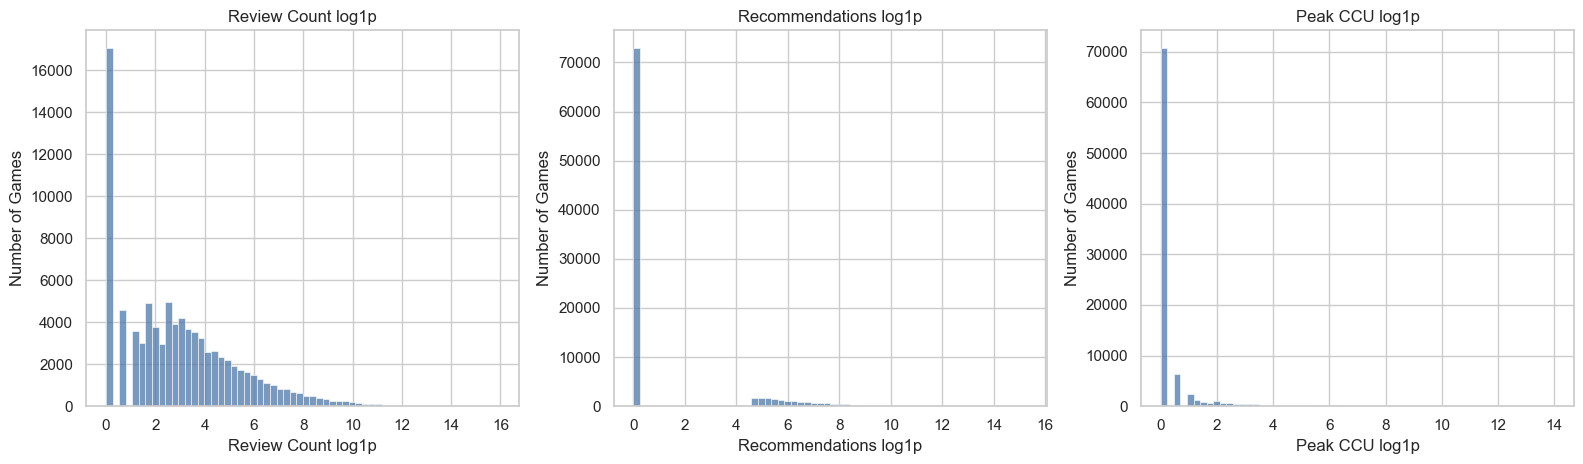

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/19_attention_metrics_log_distributions.png


,p50,p75,p90,p95,p99
review_count_calc,13.000,78.000,528.000,"1,851.300","19,452.300"
recommendations,0.000,0.000,357.000,"1,273.000","13,735.130"
peak_ccu,0.000,0.000,3.000,18.000,445.830


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
metrics_to_plot = [
    ("review_count_calc_log1p", "Review Count log1p"),
    ("recommendations_log1p", "Recommendations log1p"),
    ("peak_ccu_log1p", "Peak CCU log1p")
]
for ax, (col, label) in zip(axes, metrics_to_plot):
    sns.histplot(data=analysis_df, x=col, bins=60, ax=ax, color="#4C78A8")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Number of Games")
save_figure("19_attention_metrics_log_distributions.png")

long_tail_summary = analysis_df[["review_count_calc", "recommendations", "peak_ccu"]].quantile([0.5, 0.75, 0.9, 0.95, 0.99]).T
long_tail_summary.columns = [f"p{int(q*100)}" for q in long_tail_summary.columns]
display(long_tail_summary)

从分布上可以看到，热度指标不是接近正态分布，而是高度偏斜。对于这种数据，直接比较平均值容易被极少数头部游戏影响，因此后面会更多使用中位数、分位数和 log 变换。

## 4. 好评率分布与评论数量门槛

好评率需要结合评论数量理解。只有 1 条评论的游戏可能是 100% 好评，也可能是 0% 好评，但这种比例并不稳定。

因此，本节把 `review_count_calc >= 30` 的游戏作为相对可靠的好评率分析对象。这个阈值不是严格统计标准，而是课程项目中用于减少极小样本误导的温和处理。

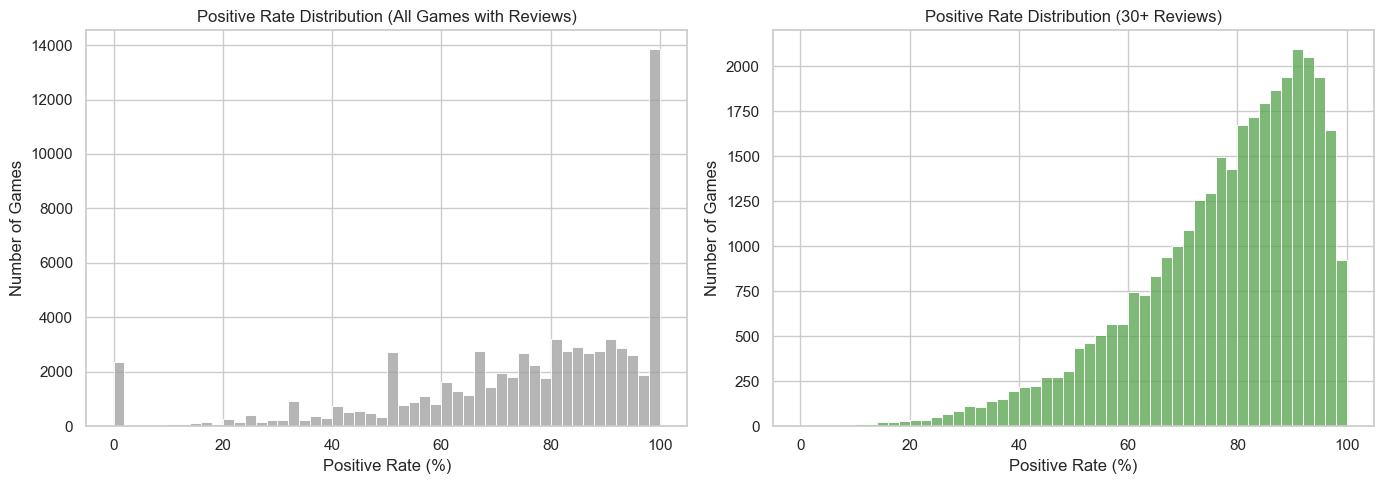

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/20_positive_rate_distribution_reliable_reviews.png


,group,game_count,median_positive_rate,mean_positive_rate
0,All games with reviews,72563,81.356,75.398
1,Games with 30+ reviews,33358,81.081,77.503


In [6]:
reliable_df = analysis_df[analysis_df["has_reliable_positive_rate"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=analysis_df[analysis_df["positive_rate_calc"].notna()], x="positive_rate_calc", bins=50, ax=axes[0], color="#9D9D9D")
axes[0].set_title("Positive Rate Distribution (All Games with Reviews)")
axes[0].set_xlabel("Positive Rate (%)")
axes[0].set_ylabel("Number of Games")

sns.histplot(data=reliable_df, x="positive_rate_calc", bins=50, ax=axes[1], color="#54A24B")
axes[1].set_title("Positive Rate Distribution (30+ Reviews)")
axes[1].set_xlabel("Positive Rate (%)")
axes[1].set_ylabel("Number of Games")
save_figure("20_positive_rate_distribution_reliable_reviews.png")

positive_rate_summary = pd.DataFrame({
    "group": ["All games with reviews", "Games with 30+ reviews"],
    "game_count": [analysis_df["positive_rate_calc"].notna().sum(), len(reliable_df)],
    "median_positive_rate": [analysis_df["positive_rate_calc"].median(), reliable_df["positive_rate_calc"].median()],
    "mean_positive_rate": [analysis_df["positive_rate_calc"].mean(), reliable_df["positive_rate_calc"].mean()],
})
display(positive_rate_summary)

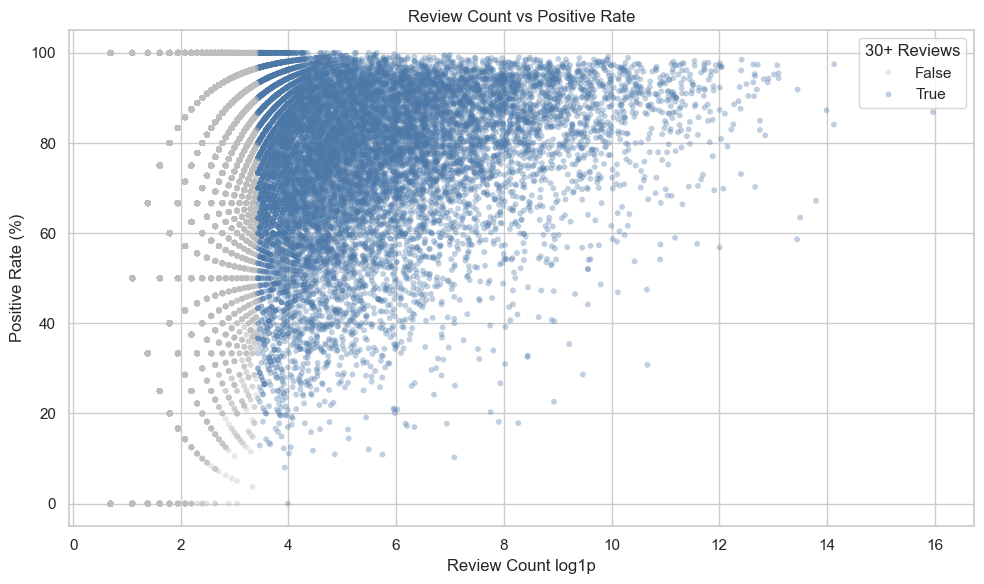

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/21_review_count_vs_positive_rate.png


In [7]:
scatter_sample = analysis_df[analysis_df["positive_rate_calc"].notna()].copy()
# 散点图使用抽样和透明度，避免 8 万多点叠在一起。
scatter_sample = scatter_sample.sample(n=min(30000, len(scatter_sample)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="review_count_calc_log1p",
    y="positive_rate_calc",
    hue="has_reliable_positive_rate",
    palette={False: "#BDBDBD", True: "#4C78A8"},
    alpha=0.35,
    linewidth=0,
    s=18
)
plt.title("Review Count vs Positive Rate")
plt.xlabel("Review Count log1p")
plt.ylabel("Positive Rate (%)")
plt.legend(title="30+ Reviews")
save_figure("21_review_count_vs_positive_rate.png")

好评率和评论数量共同说明了玩家反馈的两个维度：一个是反馈规模，一个是反馈倾向。评论数很少的游戏好评率波动更大，因此后续按类型或价格分组分析时，会优先参考评论数达到一定门槛的游戏。

## 5. 推荐数、峰值在线与评论数量之间的关系

推荐数、评论数和峰值在线人数都能反映热度，但含义并不完全相同。评论数偏向“累计反馈”，峰值在线更接近“活跃热度”，推荐数则是另一种平台信号。

本节用散点图观察这些指标之间是否存在直观关系。

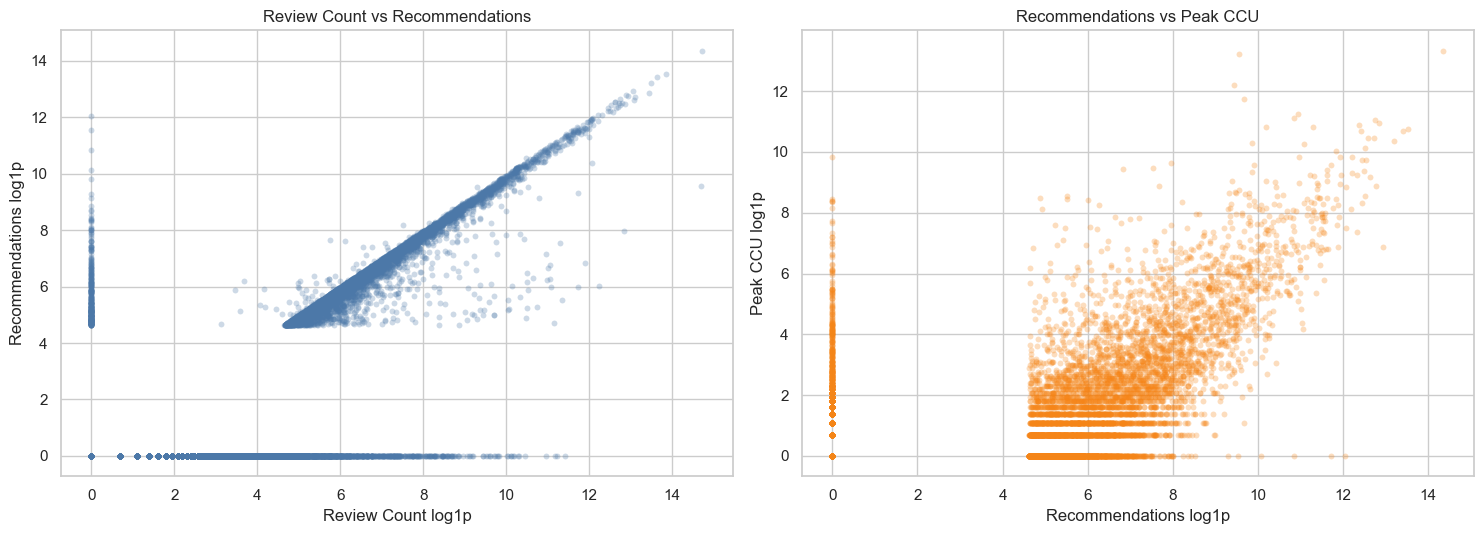

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/22_popularity_proxy_relationships.png


,review_count_calc_log1p,recommendations_log1p,peak_ccu_log1p,average_playtime_forever_log1p,positive_rate_calc
review_count_calc_log1p,1.000,0.603,0.520,0.412,-0.069
recommendations_log1p,0.603,1.000,0.636,0.493,0.046
peak_ccu_log1p,0.520,0.636,1.000,0.403,0.076
average_playtime_forever_log1p,0.412,0.493,0.403,1.000,-0.014
positive_rate_calc,-0.069,0.046,0.076,-0.014,1.000


In [8]:
relationship_sample = analysis_df.sample(n=min(35000, len(analysis_df)), random_state=7)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(
    data=relationship_sample,
    x="review_count_calc_log1p",
    y="recommendations_log1p",
    alpha=0.28,
    linewidth=0,
    s=18,
    ax=axes[0],
    color="#4C78A8"
)
axes[0].set_title("Review Count vs Recommendations")
axes[0].set_xlabel("Review Count log1p")
axes[0].set_ylabel("Recommendations log1p")

sns.scatterplot(
    data=relationship_sample,
    x="recommendations_log1p",
    y="peak_ccu_log1p",
    alpha=0.28,
    linewidth=0,
    s=18,
    ax=axes[1],
    color="#F58518"
)
axes[1].set_title("Recommendations vs Peak CCU")
axes[1].set_xlabel("Recommendations log1p")
axes[1].set_ylabel("Peak CCU log1p")
save_figure("22_popularity_proxy_relationships.png")

popularity_corr = analysis_df[[
    "review_count_calc_log1p", "recommendations_log1p", "peak_ccu_log1p",
    "average_playtime_forever_log1p", "positive_rate_calc"
]].corr(method="spearman")
display(popularity_corr)

如果评论数、推荐数和峰值在线之间呈现正相关，说明它们都在一定程度上捕捉了“玩家关注度”。但它们仍然不是同一个概念：例如单机游戏可能有较高好评和评论，但峰值在线不一定长期保持很高。

## 6. 价格、免费属性与玩家反馈/热度

市场结构 Notebook 已经说明免费游戏占比约为 15.8%。这里进一步观察免费/付费以及不同价格区间与评论规模、推荐数、峰值在线和好评率之间的关系。

注意：这仍然是相关性和分组差异分析，不能说明“价格导致热度变化”。

,price_bucket,game_count,median_review_count,mean_review_count,median_recommendations,median_peak_ccu,median_positive_rate_30plus,median_playtime,game_share
0,Free,14160,0.000,"2,431.237",0.000,0.000,77.451,0.000,0.158
1,<$5,39388,9.000,304.379,0.000,0.000,79.452,0.000,0.440
2,$5-$10,19090,16.000,732.102,0.000,0.000,82.688,0.000,0.213
3,$10-$20,12731,57.000,"2,380.991",0.000,0.000,83.498,0.000,0.142
4,$20-$40,3356,263.500,"7,850.651",228.000,2.000,81.971,0.000,0.037
5,$40+,893,149.000,"17,421.542",137.000,4.000,79.727,0.000,0.010


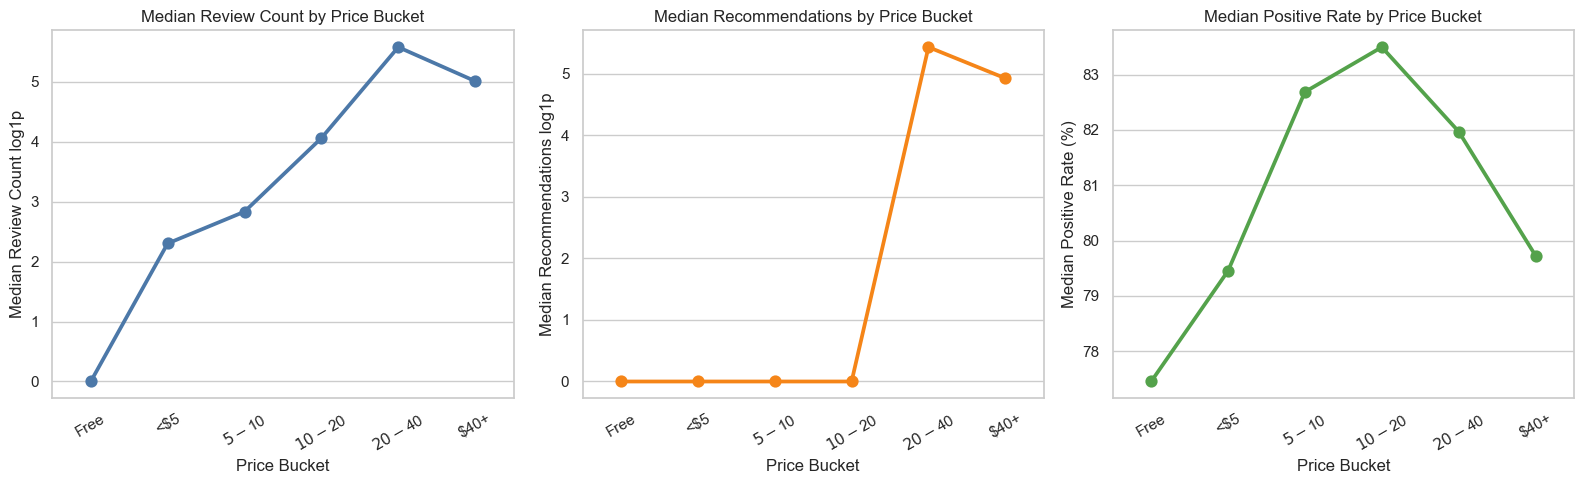

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/23_price_bucket_feedback_popularity.png


In [9]:
price_group_summary = analysis_df.groupby("price_bucket", observed=True).agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_recommendations=("recommendations", "median"),
    median_peak_ccu=("peak_ccu", "median"),
    median_positive_rate_30plus=("positive_rate_calc", lambda s: s[analysis_df.loc[s.index, "has_reliable_positive_rate"]].median()),
    median_playtime=("average_playtime_forever", "median")
).reset_index()
price_group_summary["game_share"] = price_group_summary["game_count"] / price_group_summary["game_count"].sum()
display(price_group_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_price = price_group_summary.copy()
plot_price["median_review_count_log1p"] = np.log1p(plot_price["median_review_count"])
plot_price["median_recommendations_log1p"] = np.log1p(plot_price["median_recommendations"])
plot_price["median_peak_ccu_log1p"] = np.log1p(plot_price["median_peak_ccu"])

sns.pointplot(data=plot_price, x="price_bucket", y="median_review_count_log1p", ax=axes[0], color="#4C78A8")
axes[0].set_title("Median Review Count by Price Bucket")
axes[0].set_xlabel("Price Bucket")
axes[0].set_ylabel("Median Review Count log1p")
axes[0].tick_params(axis="x", rotation=30)

sns.pointplot(data=plot_price, x="price_bucket", y="median_recommendations_log1p", ax=axes[1], color="#F58518")
axes[1].set_title("Median Recommendations by Price Bucket")
axes[1].set_xlabel("Price Bucket")
axes[1].set_ylabel("Median Recommendations log1p")
axes[1].tick_params(axis="x", rotation=30)

sns.pointplot(data=plot_price, x="price_bucket", y="median_positive_rate_30plus", ax=axes[2], color="#54A24B")
axes[2].set_title("Median Positive Rate by Price Bucket")
axes[2].set_xlabel("Price Bucket")
axes[2].set_ylabel("Median Positive Rate (%)")
axes[2].tick_params(axis="x", rotation=30)
save_figure("23_price_bucket_feedback_popularity.png")

,price_type,game_count,median_review_count,mean_review_count,median_recommendations,mean_recommendations,median_peak_ccu,mean_peak_ccu,median_positive_rate_30plus
0,Paid,75458,15.000,"1,301.138",0.000,"1,042.778",0.000,69.690,81.548
1,Free,14160,0.000,"2,431.237",0.000,831.539,0.000,251.015,77.451


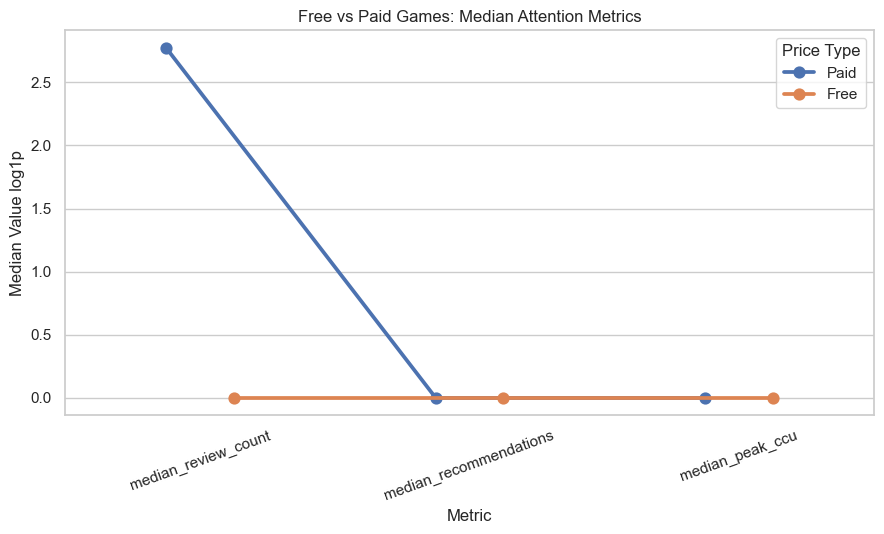

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/24_free_paid_attention_metrics.png


In [10]:
free_paid_feedback = analysis_df.groupby("is_free").agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_recommendations=("recommendations", "median"),
    mean_recommendations=("recommendations", "mean"),
    median_peak_ccu=("peak_ccu", "median"),
    mean_peak_ccu=("peak_ccu", "mean"),
    median_positive_rate_30plus=("positive_rate_calc", lambda s: s[analysis_df.loc[s.index, "has_reliable_positive_rate"]].median())
).reset_index()
free_paid_feedback["price_type"] = np.where(free_paid_feedback["is_free"], "Free", "Paid")
display(free_paid_feedback[["price_type", "game_count", "median_review_count", "mean_review_count", "median_recommendations", "mean_recommendations", "median_peak_ccu", "mean_peak_ccu", "median_positive_rate_30plus"]])

plot_fp = free_paid_feedback.melt(
    id_vars="price_type",
    value_vars=["median_review_count", "median_recommendations", "median_peak_ccu"],
    var_name="metric",
    value_name="median_value"
)
plot_fp["median_value_log1p"] = np.log1p(plot_fp["median_value"])

plt.figure(figsize=(9, 5.5))
ax = sns.pointplot(data=plot_fp, x="metric", y="median_value_log1p", hue="price_type", dodge=0.25, markers="o")
plt.title("Free vs Paid Games: Median Attention Metrics")
plt.xlabel("Metric")
plt.ylabel("Median Value log1p")
plt.xticks(rotation=20)
plt.legend(title="Price Type")
save_figure("24_free_paid_attention_metrics.png")

价格分析适合回答“不同商业模式的游戏在热度指标上是否有差异”。不过免费游戏往往更容易扩大玩家入口，付费游戏则可能对应不同的筛选机制，因此这里的结果只能作为市场观察，不能直接解释为价格本身造成了热度差异。

## 7. 平台数量与玩家反馈/热度

Notebook 04 已经分析了 Steam 游戏的平台支持结构。本节继续观察平台数量是否与评论规模、好评率、推荐数和峰值在线存在关联。

这里比较的是单平台、双平台、三平台游戏的中位数指标，避免极端头部游戏过度影响结论。

,platform_count,game_count,median_review_count,median_recommendations,median_peak_ccu,median_positive_rate_30plus,median_playtime
0,1,68960,11.000,0.000,0.000,79.630,0.000
1,2,11281,21.000,0.000,0.000,84.211,0.000
2,3,9377,40.000,0.000,0.000,83.942,0.000


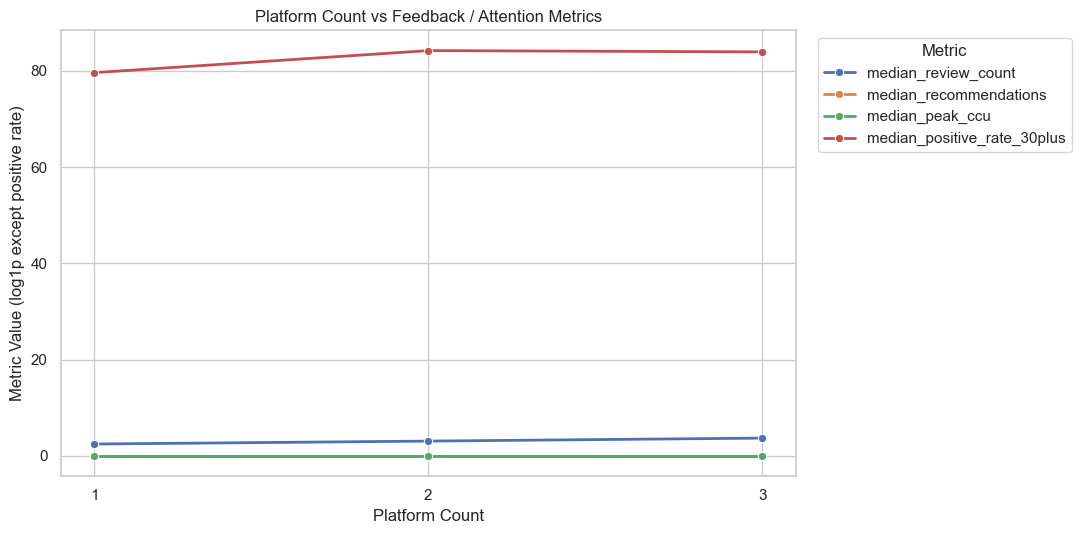

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/25_platform_count_feedback_popularity.png


In [11]:
platform_feedback = analysis_df.groupby("platform_count").agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    median_recommendations=("recommendations", "median"),
    median_peak_ccu=("peak_ccu", "median"),
    median_positive_rate_30plus=("positive_rate_calc", lambda s: s[analysis_df.loc[s.index, "has_reliable_positive_rate"]].median()),
    median_playtime=("average_playtime_forever", "median")
).reset_index()
display(platform_feedback)

plot_platform = platform_feedback.melt(
    id_vars=["platform_count", "game_count"],
    value_vars=["median_review_count", "median_recommendations", "median_peak_ccu", "median_positive_rate_30plus"],
    var_name="metric",
    value_name="value"
)
plot_platform["plot_value"] = np.where(
    plot_platform["metric"].eq("median_positive_rate_30plus"),
    plot_platform["value"],
    np.log1p(plot_platform["value"])
)

plt.figure(figsize=(11, 5.5))
sns.lineplot(data=plot_platform, x="platform_count", y="plot_value", hue="metric", marker="o", linewidth=2)
plt.title("Platform Count vs Feedback / Attention Metrics")
plt.xlabel("Platform Count")
plt.ylabel("Metric Value (log1p except positive rate)")
plt.xticks(platform_feedback["platform_count"])
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure("25_platform_count_feedback_popularity.png")

平台数量可以被理解为潜在覆盖面的一个代理变量。如果多平台游戏在热度指标上更高，可能与覆盖设备更多、开发投入更高、游戏规模更大等因素有关。但这依然不能单独解释为平台数量造成热度提升。

## 8. 类型与玩家反馈/热度

不同游戏类型面对的玩家群体和竞争环境不同。本节把游戏按 `genres` 展开成长表，统计每个类型的游戏数量、评论数量、好评率、推荐数和峰值在线。

为了避免极小类型带来误导，图表只展示游戏数量达到一定门槛的类型。

In [12]:
genre_long = explode_items(analysis_df, "genres", "genre")
genre_metrics = genre_long.merge(
    analysis_df[[
        "appid", "name", "review_count_calc", "positive_rate_calc", "recommendations", "peak_ccu",
        "average_playtime_forever", "has_reliable_positive_rate", "attention_score_descriptive"
    ]],
    on="appid",
    how="left"
)

def reliable_positive_median(s):
    idx = s.index
    mask = genre_metrics.loc[idx, "has_reliable_positive_rate"]
    return s[mask].median()

genre_summary = genre_metrics.groupby("genre").agg(
    game_count=("appid", "nunique"),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_positive_rate_30plus=("positive_rate_calc", reliable_positive_median),
    median_recommendations=("recommendations", "median"),
    median_peak_ccu=("peak_ccu", "median"),
    mean_attention_score=("attention_score_descriptive", "mean")
).reset_index()

min_genre_games = 300
genre_summary_filtered = genre_summary[genre_summary["game_count"] >= min_genre_games].copy()

display(genre_summary_filtered.sort_values("median_review_count", ascending=False).head(15))
display(genre_summary_filtered.sort_values("median_positive_rate_30plus", ascending=False).head(15))

genre_summary.to_csv(PROCESSED_DIR / "steam_reviews_popularity_genre_summary.csv", index=False)
print("Saved genre summary:", PROCESSED_DIR / "steam_reviews_popularity_genre_summary.csv")

,genre,game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score
16,Massively Multiplayer,2123,23.000,"6,596.839",66.693,0.000,0.000,0.224
31,Violent,429,21.000,145.622,61.724,0.000,0.000,-0.155
7,Design & Illustration,494,19.000,"2,203.506",79.720,0.000,0.000,0.100
4,Animation & Modeling,394,18.500,"2,680.454",77.280,0.000,0.000,0.097
24,Simulation,18570,18.000,"1,468.459",78.261,0.000,0.000,0.135
20,RPG,16342,18.000,"2,167.489",80.000,0.000,0.000,0.167
27,Strategy,17366,17.000,"1,302.745",78.723,0.000,0.000,0.105
3,Adventure,35452,17.000,"1,556.786",81.400,0.000,0.000,0.044
26,Sports,3939,15.000,"1,084.374",77.541,0.000,0.000,-0.012
2,Action,36842,15.000,"2,449.445",79.545,0.000,0.000,0.026


,genre,game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,mean_attention_score
6,Casual,38699,9.000,456.927,82.444,0.000,0.000,-0.153
15,Indie,63189,14.000,846.943,81.535,0.000,0.000,-0.042
3,Adventure,35452,17.000,"1,556.786",81.400,0.000,0.000,0.044
20,RPG,16342,18.000,"2,167.489",80.000,0.000,0.000,0.167
7,Design & Illustration,494,19.000,"2,203.506",79.720,0.000,0.000,0.100
2,Action,36842,15.000,"2,449.445",79.545,0.000,0.000,0.026
27,Strategy,17366,17.000,"1,302.745",78.723,0.000,0.000,0.105
24,Simulation,18570,18.000,"1,468.459",78.261,0.000,0.000,0.135
26,Sports,3939,15.000,"1,084.374",77.541,0.000,0.000,-0.012
21,Racing,3301,13.000,"1,002.054",77.504,0.000,0.000,-0.040


Saved genre summary: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_genre_summary.csv


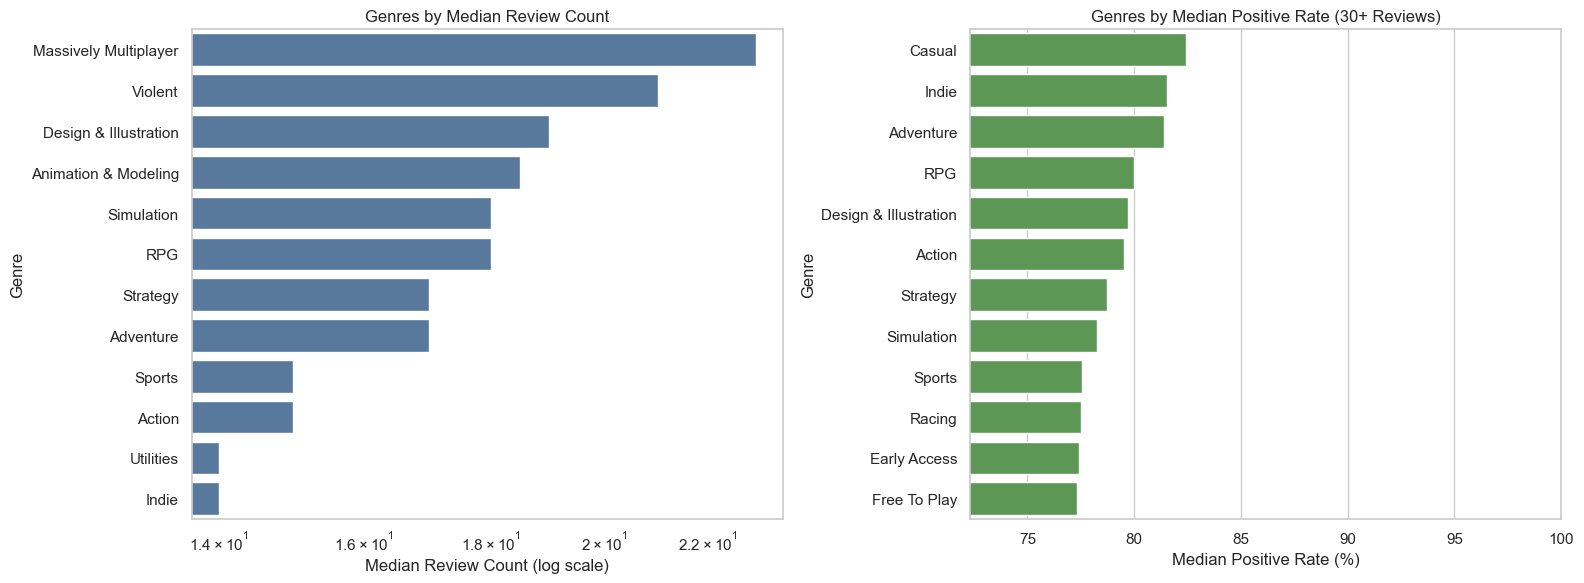

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/26_genre_feedback_popularity_comparison.png


In [13]:
plot_genre_attention = genre_summary_filtered.sort_values("median_review_count", ascending=False).head(12).copy()
plot_genre_rating = genre_summary_filtered.dropna(subset=["median_positive_rate_30plus"]).sort_values("median_positive_rate_30plus", ascending=False).head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=plot_genre_attention, y="genre", x="median_review_count", ax=axes[0], color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_title("Genres by Median Review Count")
axes[0].set_xlabel("Median Review Count (log scale)")
axes[0].set_ylabel("Genre")

sns.barplot(data=plot_genre_rating, y="genre", x="median_positive_rate_30plus", ax=axes[1], color="#54A24B")
axes[1].set_title("Genres by Median Positive Rate (30+ Reviews)")
axes[1].set_xlabel("Median Positive Rate (%)")
axes[1].set_ylabel("Genre")
axes[1].set_xlim(max(0, plot_genre_rating["median_positive_rate_30plus"].min() - 5), 100)

save_figure("26_genre_feedback_popularity_comparison.png")

类型层面的分析可以帮助回答“哪些内容方向更容易获得玩家反馈或更高评价”。这里的重点不是证明某个类型天然更好，而是识别 Steam 市场中不同内容类别的玩家反馈差异。

## 9. 发行年份、游戏年龄与热度指标

发行时间会影响热度指标的解释：老游戏有更长时间积累评论和推荐，新游戏则可能更能反映近期市场趋势。

本节按发行年份统计评论数量、好评率和峰值在线，观察时间维度上的变化。

,release_year,game_count,median_review_count,mean_review_count,median_positive_rate_30plus,median_recommendations,median_peak_ccu,total_review_count
15,2014,1525,317.000,"3,406.847",74.516,153.000,0.000,5195441
16,2015,2521,153.000,"4,384.029",74.211,0.000,0.000,11052136
17,2016,4160,86.000,"2,472.478",76.017,0.000,0.000,10285508
18,2017,5967,39.000,"2,014.917",76.451,0.000,0.000,12023008
19,2018,7443,26.000,"1,626.222",77.636,0.000,0.000,12103971
20,2019,6146,20.000,"1,361.993",81.434,0.000,0.000,8370810
21,2020,8568,18.000,"1,526.700",83.000,0.000,0.000,13080769
22,2021,8294,13.000,968.027,83.832,0.000,0.000,8028818
23,2022,9158,8.000,843.360,83.886,0.000,0.000,7723491
24,2023,12735,5.000,580.728,84.926,0.000,0.000,7395569


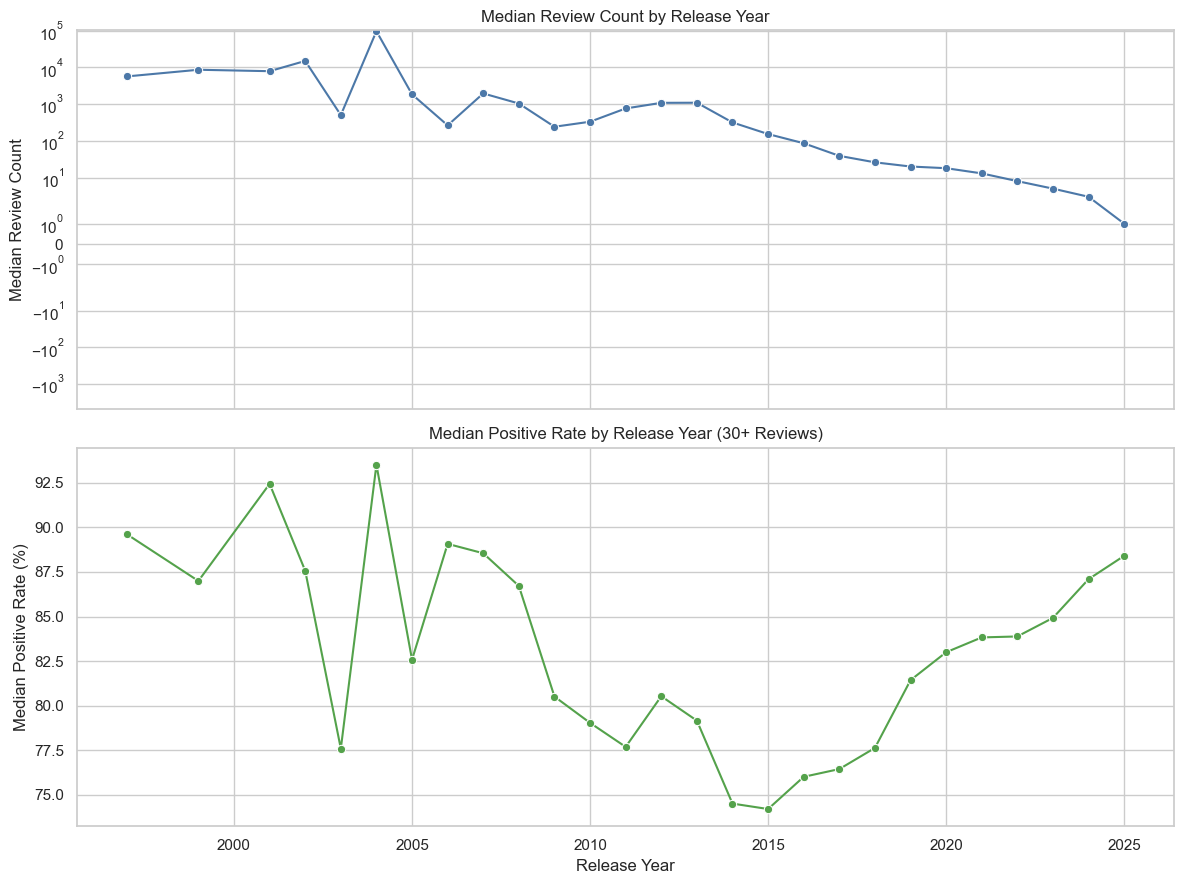

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/27_release_year_feedback_trends.png


In [14]:
year_feedback = analysis_df[analysis_df["release_year"].between(1997, 2025)].groupby("release_year").agg(
    game_count=("appid", "count"),
    median_review_count=("review_count_calc", "median"),
    mean_review_count=("review_count_calc", "mean"),
    median_positive_rate_30plus=("positive_rate_calc", lambda s: s[analysis_df.loc[s.index, "has_reliable_positive_rate"]].median()),
    median_recommendations=("recommendations", "median"),
    median_peak_ccu=("peak_ccu", "median"),
    total_review_count=("review_count_calc", "sum")
).reset_index()

display(year_feedback.tail(12))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
sns.lineplot(data=year_feedback, x="release_year", y="median_review_count", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_yscale("symlog")
axes[0].set_title("Median Review Count by Release Year")
axes[0].set_ylabel("Median Review Count")

sns.lineplot(data=year_feedback, x="release_year", y="median_positive_rate_30plus", marker="o", ax=axes[1], color="#54A24B")
axes[1].set_title("Median Positive Rate by Release Year (30+ Reviews)")
axes[1].set_xlabel("Release Year")
axes[1].set_ylabel("Median Positive Rate (%)")
save_figure("27_release_year_feedback_trends.png")

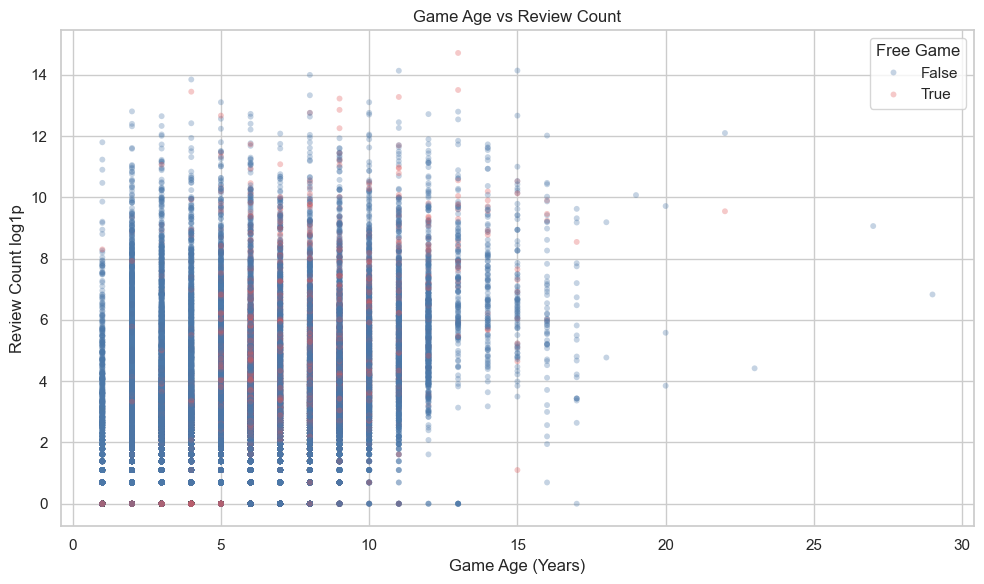

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/28_game_age_vs_review_count.png


In [15]:
age_sample = analysis_df[analysis_df["game_age_years"].notna()].sample(n=min(35000, len(analysis_df)), random_state=11)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=age_sample,
    x="game_age_years",
    y="review_count_calc_log1p",
    hue="is_free",
    palette={False: "#4C78A8", True: "#E15759"},
    alpha=0.32,
    linewidth=0,
    s=18
)
plt.title("Game Age vs Review Count")
plt.xlabel("Game Age (Years)")
plt.ylabel("Review Count log1p")
plt.legend(title="Free Game")
save_figure("28_game_age_vs_review_count.png")

时间分析提醒我们：评论数和推荐数具有累积效应。老游戏天然有更多时间获得评论，因此不能简单把评论数量直接等同于质量。后续如果要做建模，需要把发行时间或游戏年龄作为重要控制变量。

## 10. 综合相关性分析

本节把数值特征放在一起，观察它们和玩家反馈、热度指标之间的线性或单调关系。由于数据长尾明显，这里优先使用 log 变换后的热度指标，并使用 Spearman 相关系数。

相关性分析只能说明变量之间的共同变化趋势，不能说明因果关系。

,price,platform_count,game_age_years,genres_count,tags_count,review_count_calc_log1p,positive_rate_calc,recommendations_log1p,peak_ccu_log1p,average_playtime_forever_log1p,median_playtime_forever_log1p,attention_score_descriptive
price,1.000,0.061,0.015,-0.075,0.321,0.298,0.048,0.331,0.311,0.137,0.138,0.340
platform_count,0.061,1.000,0.142,0.014,0.051,0.138,0.074,0.122,0.101,0.094,0.093,0.146
game_age_years,0.015,0.142,1.000,-0.051,-0.039,0.446,-0.254,0.208,0.061,0.225,0.225,0.397
genres_count,-0.075,0.014,-0.051,1.000,0.132,0.002,-0.074,-0.028,-0.024,-0.004,-0.004,-0.004
tags_count,0.321,0.051,-0.039,0.132,1.000,0.560,0.171,0.278,0.275,0.161,0.160,0.523
review_count_calc_log1p,0.298,0.138,0.446,0.002,0.560,1.000,-0.069,0.603,0.520,0.412,0.411,0.953
positive_rate_calc,0.048,0.074,-0.254,-0.074,0.171,-0.069,1.000,0.046,0.076,-0.014,-0.014,-0.052
recommendations_log1p,0.331,0.122,0.208,-0.028,0.278,0.603,0.046,1.000,0.636,0.493,0.493,0.672
peak_ccu_log1p,0.311,0.101,0.061,-0.024,0.275,0.520,0.076,0.636,1.000,0.403,0.401,0.644
average_playtime_forever_log1p,0.137,0.094,0.225,-0.004,0.161,0.412,-0.014,0.493,0.403,1.000,1.000,0.417


Saved correlation table: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_correlation.csv


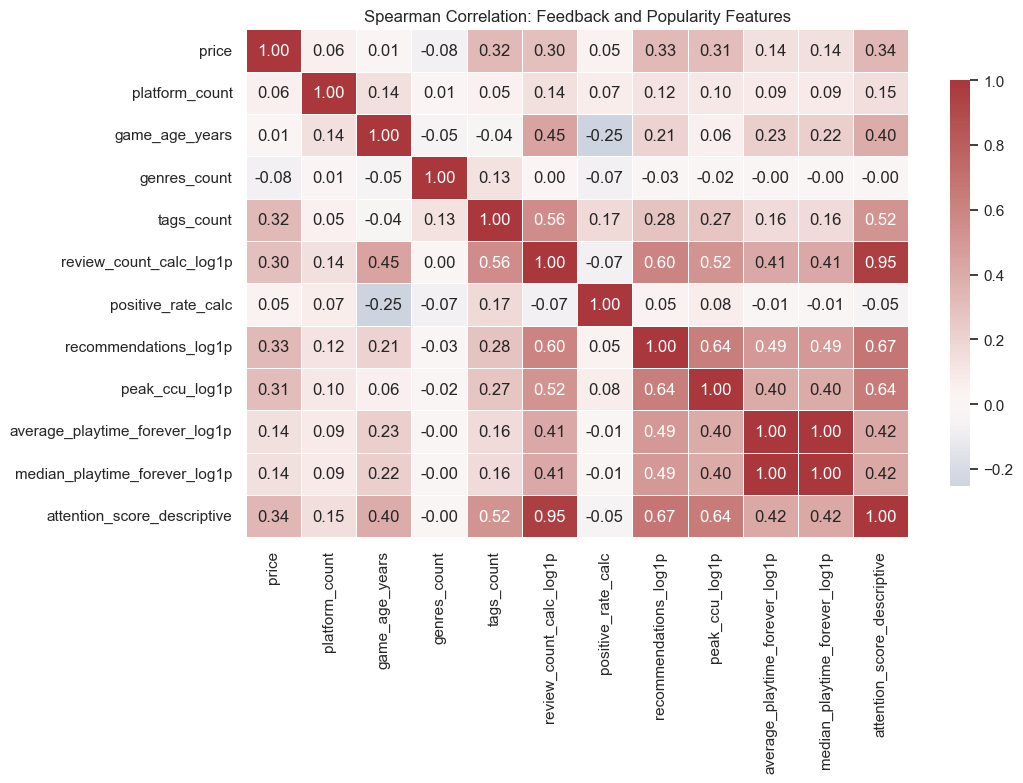

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/29_feedback_popularity_correlation_heatmap.png

Top correlations with review_count_calc_log1p:


,abs_spearman_corr
attention_score_descriptive,0.953
recommendations_log1p,0.603
tags_count,0.560
peak_ccu_log1p,0.520
game_age_years,0.446
average_playtime_forever_log1p,0.412
median_playtime_forever_log1p,0.411
price,0.298



Top correlations with positive_rate_calc:


,abs_spearman_corr
game_age_years,0.254
tags_count,0.171
peak_ccu_log1p,0.076
platform_count,0.074
genres_count,0.074
review_count_calc_log1p,0.069
attention_score_descriptive,0.052
price,0.048



Top correlations with recommendations_log1p:


,abs_spearman_corr
attention_score_descriptive,0.672
peak_ccu_log1p,0.636
review_count_calc_log1p,0.603
average_playtime_forever_log1p,0.493
median_playtime_forever_log1p,0.493
price,0.331
tags_count,0.278
game_age_years,0.208



Top correlations with peak_ccu_log1p:


,abs_spearman_corr
attention_score_descriptive,0.644
recommendations_log1p,0.636
review_count_calc_log1p,0.520
average_playtime_forever_log1p,0.403
median_playtime_forever_log1p,0.401
price,0.311
tags_count,0.275
platform_count,0.101



Top correlations with attention_score_descriptive:


,abs_spearman_corr
review_count_calc_log1p,0.953
recommendations_log1p,0.672
peak_ccu_log1p,0.644
tags_count,0.523
average_playtime_forever_log1p,0.417
median_playtime_forever_log1p,0.416
game_age_years,0.397
price,0.340


In [16]:
corr_columns = [
    "price", "platform_count", "game_age_years", "genres_count", "tags_count",
    "review_count_calc_log1p", "positive_rate_calc", "recommendations_log1p", "peak_ccu_log1p",
    "average_playtime_forever_log1p", "median_playtime_forever_log1p", "attention_score_descriptive"
]
corr_columns = [col for col in corr_columns if col in analysis_df.columns]
corr_df = analysis_df[corr_columns].corr(method="spearman")

display(corr_df)
corr_df.to_csv(PROCESSED_DIR / "steam_reviews_popularity_correlation.csv")
print("Saved correlation table:", PROCESSED_DIR / "steam_reviews_popularity_correlation.csv")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Spearman Correlation: Feedback and Popularity Features")
save_figure("29_feedback_popularity_correlation_heatmap.png")

focus_targets = ["review_count_calc_log1p", "positive_rate_calc", "recommendations_log1p", "peak_ccu_log1p", "attention_score_descriptive"]
for target in [col for col in focus_targets if col in corr_df.columns]:
    print(f"\nTop correlations with {target}:")
    display(corr_df[target].drop(target).abs().sort_values(ascending=False).head(8).to_frame("abs_spearman_corr"))

相关性热力图可以快速发现哪些特征和热度指标一起变化。比如评论数、推荐数和峰值在线如果相关性较高，说明它们都能捕捉到一部分玩家关注度。但好评率可能与热度指标不完全一致，这也说明“更热门”和“评价更正面”不是同一个问题。

## 11. 2024 到 2025 快照中的反馈与热度变化

本节轻量比较 May 2024 和 March 2025 两个 cleaned 快照中的评论与热度指标。这里不做逐游戏追踪建模，只比较整体规模和中位数，帮助报告中体现“平台生态变化”的时间视角。

In [17]:
def normalize_column_name(name):
    return str(name).strip().lower().replace(" ", "_").replace("-", "_")


def read_snapshot_feedback(path, label):
    if not path.exists():
        print(f"Snapshot file not found: {path}")
        return None
    header = pd.read_csv(path, nrows=0).columns.tolist()
    normalized_to_original = {normalize_column_name(col): col for col in header}
    wanted = ["appid", "price", "positive", "negative", "recommendations", "peak_ccu", "average_playtime_forever"]
    usecols = []
    rename_map = {}
    for standard in wanted:
        original = normalized_to_original.get(standard)
        if original is not None:
            usecols.append(original)
            rename_map[original] = standard
    snap = pd.read_csv(path, usecols=usecols, low_memory=False).rename(columns=rename_map)
    snap["snapshot"] = label
    for col in ["price", "positive", "negative", "recommendations", "peak_ccu", "average_playtime_forever"]:
        if col in snap.columns:
            snap[col] = pd.to_numeric(snap[col], errors="coerce")
    if {"positive", "negative"}.issubset(snap.columns):
        snap["review_count_calc"] = snap["positive"].fillna(0) + snap["negative"].fillna(0)
        snap["positive_rate_calc"] = np.where(
            snap["review_count_calc"] > 0,
            snap["positive"] / snap["review_count_calc"] * 100,
            np.nan
        )
        snap["has_reliable_positive_rate"] = snap["review_count_calc"] >= 30
    if "price" in snap.columns:
        snap["is_free"] = snap["price"].fillna(0).eq(0)
    return snap

snap_may = read_snapshot_feedback(RAW_DIR / "games_may2024_cleaned.csv", "May 2024")
snap_mar = read_snapshot_feedback(RAW_DIR / "games_march2025_cleaned.csv", "March 2025")

if snap_may is not None and snap_mar is not None:
    snapshot_feedback = pd.concat([snap_may, snap_mar], ignore_index=True)
    snapshot_feedback_summary = snapshot_feedback.groupby("snapshot").agg(
        unique_appids=("appid", "nunique"),
        total_review_count=("review_count_calc", "sum"),
        median_review_count=("review_count_calc", "median"),
        total_recommendations=("recommendations", "sum"),
        median_recommendations=("recommendations", "median"),
        max_peak_ccu=("peak_ccu", "max"),
        median_positive_rate_30plus=("positive_rate_calc", lambda s: s[snapshot_feedback.loc[s.index, "has_reliable_positive_rate"]].median()),
        free_game_share=("is_free", "mean")
    ).reset_index()
    display(snapshot_feedback_summary)
else:
    snapshot_feedback_summary = None
    print("未能同时读取两个快照，因此跳过反馈与热度快照对比。")

,snapshot,unique_appids,total_review_count,median_review_count,total_recommendations,median_recommendations,max_peak_ccu,median_positive_rate_30plus,free_game_share
0,March 2025,89618,132607623,13.000,90460506,0.000,1212356,81.081,0.158
1,May 2024,83646,124126364,15.000,83936893,0.000,1362469,80.952,0.153


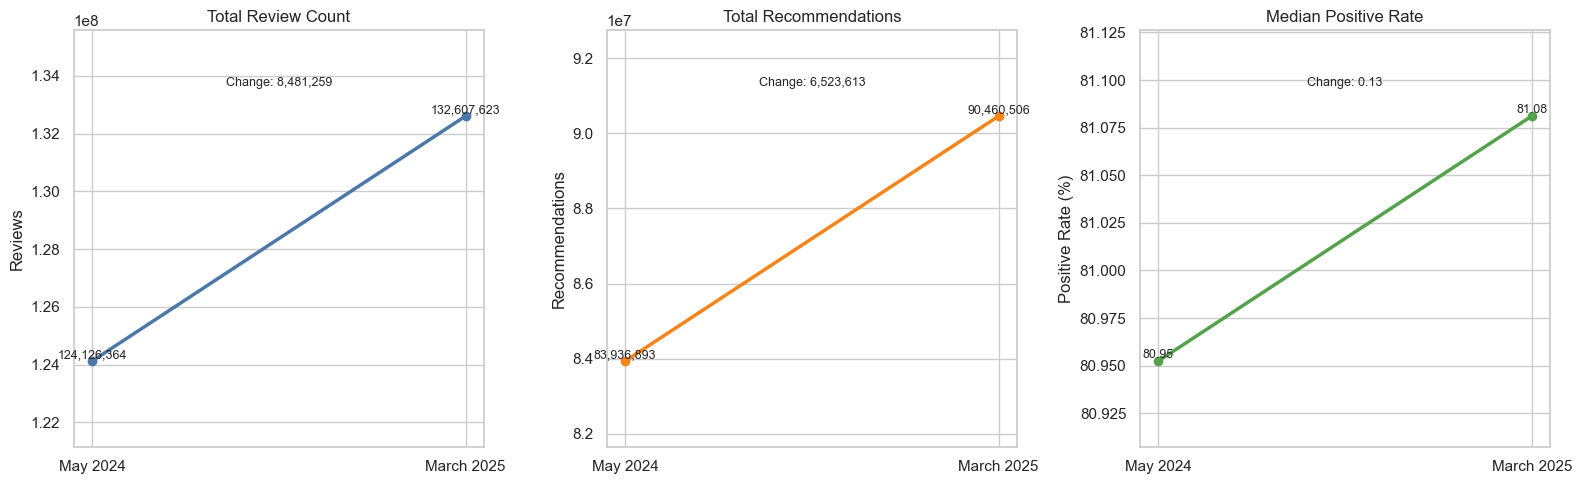

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/30_snapshot_feedback_popularity_comparison.png


In [18]:
if snapshot_feedback_summary is not None:
    plot_snapshot = snapshot_feedback_summary.set_index("snapshot").loc[["May 2024", "March 2025"]].reset_index()
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    def draw_change(ax, metric, title, ylabel, formatter, color):
        values = plot_snapshot[metric].to_numpy(dtype=float)
        ax.plot([0, 1], values, marker="o", linewidth=2.5, color=color)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(plot_snapshot["snapshot"])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        lower, upper = np.nanmin(values), np.nanmax(values)
        padding = (upper - lower) * 0.35 if upper != lower else max(abs(upper) * 0.1, 1)
        ax.set_ylim(lower - padding, upper + padding)
        for x, value in zip([0, 1], values):
            ax.text(x, value, formatter(value), ha="center", va="bottom", fontsize=9)
        delta = values[1] - values[0]
        ax.text(0.5, upper + padding * 0.35, f"Change: {formatter(delta)}", ha="center", fontsize=9)

    draw_change(axes[0], "total_review_count", "Total Review Count", "Reviews", lambda x: f"{x:,.0f}", "#4C78A8")
    draw_change(axes[1], "total_recommendations", "Total Recommendations", "Recommendations", lambda x: f"{x:,.0f}", "#F58518")
    draw_change(axes[2], "median_positive_rate_30plus", "Median Positive Rate", "Positive Rate (%)", lambda x: f"{x:.2f}", "#54A24B")
    save_figure("30_snapshot_feedback_popularity_comparison.png")

快照对比可以说明平台整体反馈规模是否随游戏数量增长而变化。不过两个快照之间可能存在采集口径和清洗口径差异，因此这里仍然只作为描述性观察。

## 12. 热门游戏样例与结果保存

最后，本节列出综合热度分数较高的游戏样例，并保存本 Notebook 生成的几个 summary 表格，方便后续报告或 Notebook 07 汇总时复用。

这里的综合热度分数不是机器学习模型，只是把评论数、推荐数和峰值在线人数进行 log 标准化后的描述性排序。

In [19]:
top_attention_games = analysis_df.sort_values("attention_score_descriptive", ascending=False).head(20)[[
    "appid", "name", "release_year", "price", "is_free", "review_count_calc", "positive_rate_calc",
    "recommendations", "peak_ccu", "average_playtime_forever", "genres"
]].copy()

display(top_attention_games)

top_attention_path = PROCESSED_DIR / "steam_reviews_popularity_top_attention_games.csv"
top_attention_games.to_csv(top_attention_path, index=False)
metric_summary.to_csv(PROCESSED_DIR / "steam_reviews_popularity_metric_summary.csv", index=False)
price_group_summary.to_csv(PROCESSED_DIR / "steam_reviews_popularity_price_summary.csv", index=False)
platform_feedback.to_csv(PROCESSED_DIR / "steam_reviews_popularity_platform_summary.csv", index=False)
if snapshot_feedback_summary is not None:
    snapshot_feedback_summary.to_csv(PROCESSED_DIR / "steam_reviews_popularity_snapshot_summary.csv", index=False)

print("Saved:")
for path in [
    top_attention_path,
    PROCESSED_DIR / "steam_reviews_popularity_metric_summary.csv",
    PROCESSED_DIR / "steam_reviews_popularity_price_summary.csv",
    PROCESSED_DIR / "steam_reviews_popularity_platform_summary.csv",
    PROCESSED_DIR / "steam_reviews_popularity_genre_summary.csv",
    PROCESSED_DIR / "steam_reviews_popularity_correlation.csv",
    PROCESSED_DIR / "steam_reviews_popularity_snapshot_summary.csv",
]:
    if path.exists():
        print("-", path)

,appid,name,release_year,price,is_free,review_count_calc,positive_rate_calc,recommendations,peak_ccu,average_playtime_forever,genres
0,730,Counter-Strike 2,2012,0.000,True,8615921,86.825,4401572,1212356,33189,"['Action', 'Free To Play']"
1,578080,PUBG: BATTLEGROUNDS,2017,0.000,True,2512396,59.225,1732007,616738,0,"['Action', 'Adventure', 'Massively Multiplayer..."
7,252490,Rust,2018,39.990,False,1195980,87.268,992825,200902,21195,"['Action', 'Adventure', 'Indie', 'Massively Mu..."
3,271590,Grand Theft Auto V Legacy,2015,0.000,True,1969962,87.309,1803063,117698,19323,"['Action', 'Adventure']"
2,570,Dota 2,2013,0.000,True,2449800,81.577,14337,555977,43031,"['Action', 'Strategy', 'Free To Play']"
4,359550,Tom Clancy's Rainbow Six® Siege,2015,3.990,False,1371209,84.069,1165929,89916,14204,['Action']
56729,431960,Wallpaper Engine,2018,4.990,False,872956,98.037,809225,120461,0,"['Casual', 'Indie', 'Animation & Modeling', 'D..."
182,2246340,Monster Hunter Wilds,2025,69.990,False,132740,56.254,88048,703236,1765,"['Action', 'Adventure', 'RPG']"
13,413150,Stardew Valley,2016,14.990,False,854853,98.428,729406,67309,4871,"['Indie', 'RPG', 'Simulation']"
12,1245620,ELDEN RING,2022,59.990,False,1029858,92.842,749109,46121,11768,"['Action', 'RPG']"


Saved:
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_top_attention_games.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_metric_summary.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_price_summary.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_platform_summary.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_genre_summary.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_correlation.csv
- /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_reviews_popularity_snapshot_summary.csv


## 13. 初步洞察总结

本节根据前面的实际运行结果生成一段中文总结。总结只使用代码已经计算出的指标，不编造未验证结论。

In [20]:
total_games = len(analysis_df)
games_with_reviews = int(analysis_df["has_reviews"].sum())
games_with_reliable_reviews = int(analysis_df["has_reliable_positive_rate"].sum())
median_positive_rate_reliable = analysis_df.loc[analysis_df["has_reliable_positive_rate"], "positive_rate_calc"].median()
median_review_count = analysis_df["review_count_calc"].median()
mean_review_count = analysis_df["review_count_calc"].mean()
median_recommendations = analysis_df["recommendations"].median()
median_peak_ccu = analysis_df["peak_ccu"].median()

top_corr_review = corr_df["review_count_calc_log1p"].drop("review_count_calc_log1p").abs().sort_values(ascending=False).head(1)
top_corr_attention = corr_df["attention_score_descriptive"].drop("attention_score_descriptive").abs().sort_values(ascending=False).head(1)

top_review_genre = genre_summary_filtered.sort_values("median_review_count", ascending=False).iloc[0]["genre"] if len(genre_summary_filtered) else "N/A"
top_positive_genre = genre_summary_filtered.dropna(subset=["median_positive_rate_30plus"]).sort_values("median_positive_rate_30plus", ascending=False).iloc[0]["genre"] if len(genre_summary_filtered.dropna(subset=["median_positive_rate_30plus"])) else "N/A"

snapshot_text = ""
if snapshot_feedback_summary is not None:
    may_reviews = snapshot_feedback_summary.loc[snapshot_feedback_summary["snapshot"] == "May 2024", "total_review_count"].iloc[0]
    mar_reviews = snapshot_feedback_summary.loc[snapshot_feedback_summary["snapshot"] == "March 2025", "total_review_count"].iloc[0]
    snapshot_text = f"快照对比中，May 2024 到 March 2025 的总评论数从 {may_reviews:,.0f} 增加到 {mar_reviews:,.0f}，说明数据中的玩家反馈规模随平台内容扩张继续增加。"
else:
    snapshot_text = "本次未能生成两个快照的反馈规模对比。"

summary_md = f"""
### 可写入报告的初步结论

1. 当前数据集中共有 **{total_games:,}** 款游戏，其中 **{games_with_reviews:,}** 款至少有 1 条评论，**{games_with_reliable_reviews:,}** 款达到 30 条及以上评论。说明虽然数据规模很大，但并不是每款游戏都有足够稳定的玩家反馈。

2. 评论数量呈现明显长尾分布。评论数中位数为 **{median_review_count:,.0f}**，均值为 **{mean_review_count:,.2f}**，两者差距较大，说明少数头部游戏显著拉高了平均水平。

3. 对评论数达到 30 条以上的游戏，好评率中位数约为 **{median_positive_rate_reliable:.2f}%**。这比直接观察所有有评论游戏更稳健，因为极少评论游戏的好评率波动很大。

4. 推荐数和峰值在线人数同样呈现长尾。推荐数中位数为 **{median_recommendations:,.0f}**，峰值在线人数中位数为 **{median_peak_ccu:,.0f}**，说明多数游戏在这些热度指标上较低，少数头部游戏贡献了大量关注度。

5. 类型层面，在样本数量达到门槛的类型中，按评论数中位数较高的类型代表是 **{top_review_genre}**；按 30 条以上评论游戏的好评率中位数较高的类型代表是 **{top_positive_genre}**。这说明“更容易被关注”和“评价更正面”可能对应不同的内容方向。

6. 相关性分析中，与评论数 log 指标绝对相关性最高的变量是 **{top_corr_review.index[0]}**，与综合热度分数绝对相关性最高的变量是 **{top_corr_attention.index[0]}**。这些结果可以作为后续 PCA、聚类或简单预测分析的候选特征线索。

7. {snapshot_text}

8. 本 Notebook 仍然属于描述性分析，不能直接说明因果关系。后续可以进一步在 Notebook 06 中研究标签和类型定位，或在项目末尾把这些特征用于简单的相似游戏推荐系统。
"""

display(Markdown(summary_md))


### 可写入报告的初步结论

1. 当前数据集中共有 **89,618** 款游戏，其中 **72,563** 款至少有 1 条评论，**33,358** 款达到 30 条及以上评论。说明虽然数据规模很大，但并不是每款游戏都有足够稳定的玩家反馈。

2. 评论数量呈现明显长尾分布。评论数中位数为 **13**，均值为 **1,479.70**，两者差距较大，说明少数头部游戏显著拉高了平均水平。

3. 对评论数达到 30 条以上的游戏，好评率中位数约为 **81.08%**。这比直接观察所有有评论游戏更稳健，因为极少评论游戏的好评率波动很大。

4. 推荐数和峰值在线人数同样呈现长尾。推荐数中位数为 **0**，峰值在线人数中位数为 **0**，说明多数游戏在这些热度指标上较低，少数头部游戏贡献了大量关注度。

5. 类型层面，在样本数量达到门槛的类型中，按评论数中位数较高的类型代表是 **Massively Multiplayer**；按 30 条以上评论游戏的好评率中位数较高的类型代表是 **Casual**。这说明“更容易被关注”和“评价更正面”可能对应不同的内容方向。

6. 相关性分析中，与评论数 log 指标绝对相关性最高的变量是 **attention_score_descriptive**，与综合热度分数绝对相关性最高的变量是 **review_count_calc_log1p**。这些结果可以作为后续 PCA、聚类或简单预测分析的候选特征线索。

7. 快照对比中，May 2024 到 March 2025 的总评论数从 124,126,364 增加到 132,607,623，说明数据中的玩家反馈规模随平台内容扩张继续增加。

8. 本 Notebook 仍然属于描述性分析，不能直接说明因果关系。后续可以进一步在 Notebook 06 中研究标签和类型定位，或在项目末尾把这些特征用于简单的相似游戏推荐系统。
